In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_json("../data/processed/restaurantes_clean.json")
print(f"Registros: {len(df)}")
df.head()

Registros: 4002


,osm_id,tipo_osm,amenity,nombre,cocina,ciudad,calle,cp,telefono,web,horario,lat,lon
0,255173940,node,restaurant,sidrería poniente,regional,NaN,NaN,NaN,NaN,NaN,NaN,43.537488,-5.684026
1,255173941,node,restaurant,el llavianu,regional,NaN,Plaza de la Ciudad de La Habana,33212.0,NaN,NaN,NaN,43.536840,-5.684046
2,282215802,node,restaurant,mesón el puente romano,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.350419,-5.132564
3,282237374,node,restaurant,restaurante la fabada,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.347102,-5.088374
4,282238090,node,restaurant,casa manuela,NaN,NaN,NaN,NaN,+34 984 508 135,NaN,NaN,43.351354,-5.129540


In [2]:
# Usamos las columnas que tienen suficientes datos
df_model = df[["amenity", "cocina", "ciudad"]].copy()

# Rellena nulos con "desconocido"
df_model = df_model.fillna("desconocido")

# Elimina clases con muy pocos ejemplos (menos de 10)
conteo = df_model["amenity"].value_counts()
clases_validas = conteo[conteo >= 10].index
df_model = df_model[df_model["amenity"].isin(clases_validas)]

print(f"Registros para entrenar: {len(df_model)}")
print(df_model["amenity"].value_counts())

Registros para entrenar: 4002
amenity
restaurant    1791
cafe           857
bar            705
pub            479
fast_food      170
Name: count, dtype: int64


In [3]:
le_cocina = LabelEncoder()
le_ciudad = LabelEncoder()
le_amenity = LabelEncoder()

df_model["cocina_enc"] = le_cocina.fit_transform(df_model["cocina"])
df_model["ciudad_enc"] = le_ciudad.fit_transform(df_model["ciudad"])
df_model["amenity_enc"] = le_amenity.fit_transform(df_model["amenity"])

X = df_model[["cocina_enc", "ciudad_enc"]].values
y = df_model["amenity_enc"].values

print(f"Features shape: {X.shape}")
print(f"Clases: {le_amenity.classes_}")

Features shape: (4002, 2)
Clases: ['bar' 'cafe' 'fast_food' 'pub' 'restaurant']


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report

# Usa class_weight="balanced" para compensar el desbalance
clf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",  # <- clave
    random_state=42,
    max_depth=10
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scores = cross_val_score(clf_balanced, X_train, y_train, cv=5, scoring="f1_weighted")
print(f"F1 weighted media (CV): {scores.mean():.3f} ± {scores.std():.3f}")

clf_balanced.fit(X_train, y_train)
y_pred_balanced = clf_balanced.predict(X_test)

print(f"\nAccuracy test: {clf_balanced.score(X_test, y_test):.3f}")
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_balanced, target_names=le_amenity.classes_))

F1 weighted media (CV): 0.380 ± 0.006

Accuracy test: 0.367

Reporte de clasificación:
              precision    recall  f1-score   support

         bar       0.24      0.06      0.10       141
        cafe       0.37      0.19      0.25       172
   fast_food       0.56      0.65      0.60        34
         pub       0.16      0.80      0.27        96
  restaurant       0.91      0.43      0.58       358

    accuracy                           0.37       801
   macro avg       0.45      0.43      0.36       801
weighted avg       0.57      0.37      0.39       801



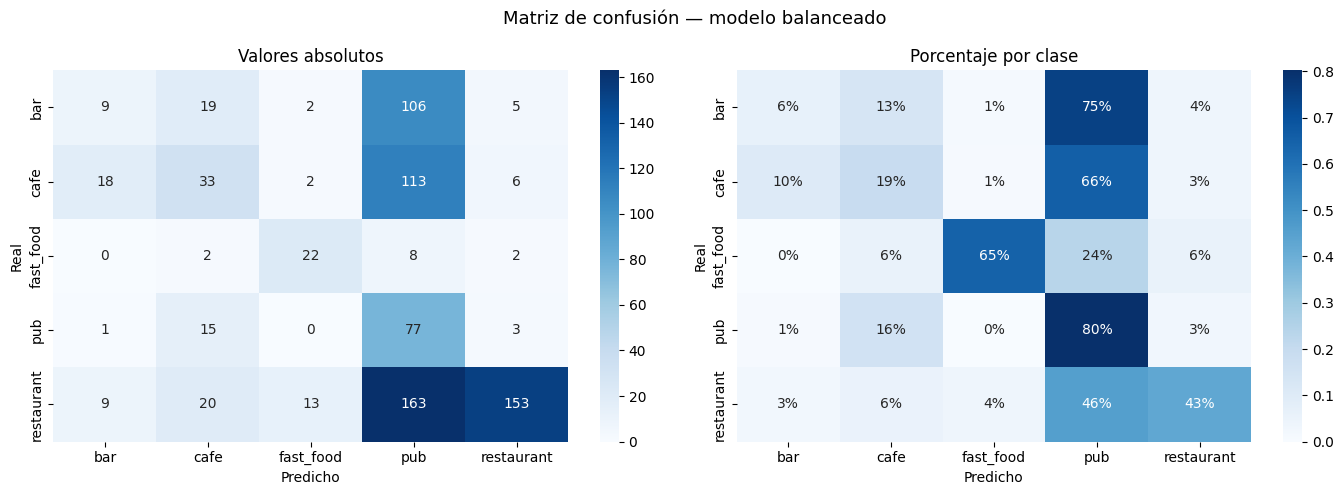

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_balanced = confusion_matrix(y_test, y_pred_balanced)

# Normaliza por fila para ver porcentajes reales
cm_norm = cm_balanced.astype(float) / cm_balanced.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absoluta
sns.heatmap(cm_balanced, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_amenity.classes_,
            yticklabels=le_amenity.classes_, ax=axes[0])
axes[0].set_title("Valores absolutos")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

# Normalizada
sns.heatmap(cm_norm, annot=True, fmt=".0%", cmap="Blues",
            xticklabels=le_amenity.classes_,
            yticklabels=le_amenity.classes_, ax=axes[1])
axes[1].set_title("Porcentaje por clase")
axes[1].set_xlabel("Predicho")
axes[1].set_ylabel("Real")

plt.suptitle("Matriz de confusión — modelo balanceado", fontsize=13)
plt.tight_layout()
plt.savefig("../docs/matriz_confusion_balanceada.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
def predecir_tipo_local(cocina: str, ciudad: str) -> str:
    cocina = cocina.lower().strip()
    ciudad = ciudad.lower().strip()

    if cocina not in le_cocina.classes_:
        cocina = "desconocido"
    if ciudad not in le_ciudad.classes_:
        ciudad = "desconocido"

    cocina_enc = le_cocina.transform([cocina])[0]
    ciudad_enc = le_ciudad.transform([ciudad])[0]

    pred = clf_balanced.predict([[cocina_enc, ciudad_enc]])[0]
    proba = clf_balanced.predict_proba([[cocina_enc, ciudad_enc]])[0]

    clase = le_amenity.inverse_transform([pred])[0]
    confianza = proba.max()

    print(f"Predicción: {clase} (confianza: {confianza:.0%})")
    for c, p in zip(le_amenity.classes_, proba):
        print(f"  {c}: {p:.0%}")
    return clase

# Pruebas
predecir_tipo_local("regional", "oviedo")
predecir_tipo_local("pizza", "gijón")
predecir_tipo_local("burger", "avilés")

Predicción: restaurant (confianza: 82%)
  bar: 0%
  cafe: 13%
  fast_food: 4%
  pub: 1%
  restaurant: 82%
Predicción: fast_food (confianza: 71%)
  bar: 0%
  cafe: 1%
  fast_food: 71%
  pub: 0%
  restaurant: 28%
Predicción: restaurant (confianza: 76%)
  bar: 0%
  cafe: 2%
  fast_food: 21%
  pub: 0%
  restaurant: 76%


'restaurant'

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Validación cruzada 5 folds
scores = cross_val_score(clf, X_train, y_train, cv=5, scoring="accuracy")
print(f"Accuracy media (CV): {scores.mean():.3f} ± {scores.std():.3f}")

# Entrenamiento final
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"\nAccuracy test: {clf.score(X_test, y_test):.3f}")

Accuracy media (CV): 0.458 ± 0.007

Accuracy test: 0.482


In [8]:
print(classification_report(
    y_test, y_pred,
    target_names=le_amenity.classes_
))

              precision    recall  f1-score   support

         bar       0.43      0.04      0.08       141
        cafe       0.42      0.26      0.32       172
   fast_food       0.59      0.65      0.62        34
         pub       0.25      0.03      0.06        96
  restaurant       0.49      0.87      0.63       358

    accuracy                           0.48       801
   macro avg       0.44      0.37      0.34       801
weighted avg       0.44      0.48      0.40       801



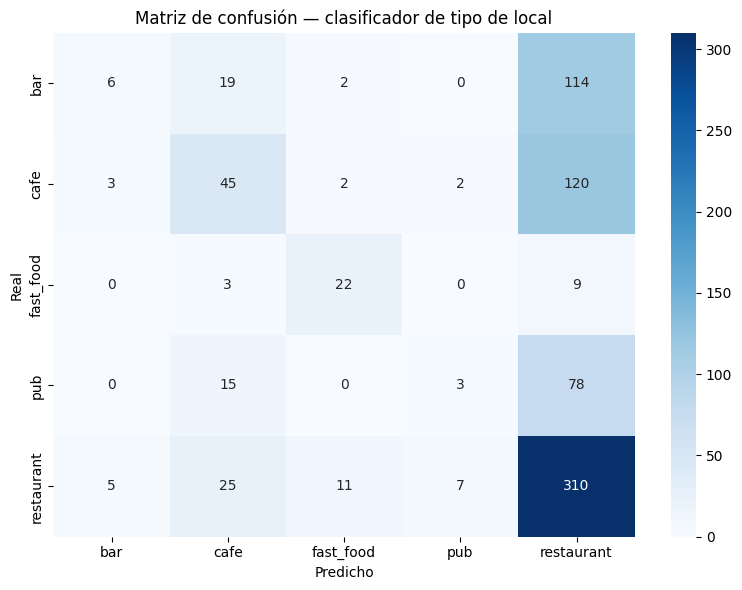

In [9]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_amenity.classes_,
    yticklabels=le_amenity.classes_,
    ax=ax
)
ax.set_title("Matriz de confusión — clasificador de tipo de local")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig("../docs/matriz_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

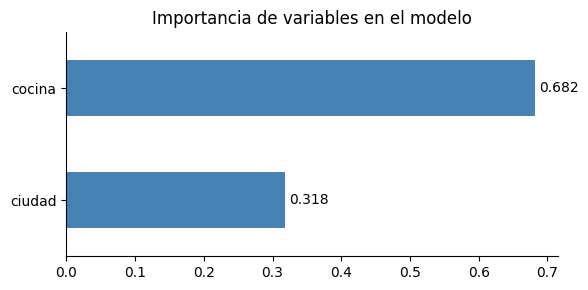

In [10]:
importancias = pd.Series(
    clf.feature_importances_,
    index=["cocina", "ciudad"]
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 3))
importancias.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Importancia de variables en el modelo")
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../docs/importancia_features.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
def predecir_tipo_local(cocina: str, ciudad: str) -> str:
    """
    Dado una cocina y una ciudad predice el tipo de local.
    """
    cocina  = cocina.lower().strip()
    ciudad  = ciudad.lower().strip()

    # Maneja valores no vistos en entrenamiento
    if cocina not in le_cocina.classes_:
        cocina = "desconocido"
    if ciudad not in le_ciudad.classes_:
        ciudad = "desconocido"

    cocina_enc = le_cocina.transform([cocina])[0]
    ciudad_enc = le_ciudad.transform([ciudad])[0]

    pred = clf.predict([[cocina_enc, ciudad_enc]])[0]
    return le_amenity.inverse_transform([pred])[0]


# Pruebas
print(predecir_tipo_local("regional", "oviedo"))
print(predecir_tipo_local("pizza", "gijón"))
print(predecir_tipo_local("burger", "avilés"))

restaurant
fast_food
restaurant


In [12]:
# Recarga el dataset limpio
df = pd.read_json("../data/processed/restaurantes_clean.json")

df_model2 = df.copy()
df_model2 = df_model2.fillna("desconocido")

# Feature: tiene teléfono
df_model2["tiene_telefono"] = (df["telefono"].notna()).astype(int)

# Feature: tiene web
df_model2["tiene_web"] = (df["web"].notna()).astype(int)

# Feature: tiene horario
df_model2["tiene_horario"] = (df["horario"].notna()).astype(int)

# Feature: tiene cocina especificada
df_model2["tiene_cocina"] = (df["cocina"].notna()).astype(int)

# Encodings
from sklearn.preprocessing import LabelEncoder
le_cocina2  = LabelEncoder()
le_ciudad2  = LabelEncoder()
le_amenity2 = LabelEncoder()

df_model2["cocina_enc"] = le_cocina2.fit_transform(df_model2["cocina"])
df_model2["ciudad_enc"] = le_ciudad2.fit_transform(df_model2["ciudad"])
df_model2["amenity_enc"] = le_amenity2.fit_transform(df_model2["amenity"])

# Filtra clases con menos de 10 ejemplos
conteo = df_model2["amenity"].value_counts()
clases_validas = conteo[conteo >= 10].index
df_model2 = df_model2[df_model2["amenity"].isin(clases_validas)]

X2 = df_model2[[
    "cocina_enc", "ciudad_enc",
    "tiene_telefono", "tiene_web",
    "tiene_horario", "tiene_cocina"
]].values
y2 = df_model2["amenity_enc"].values

print(f"Features shape: {X2.shape}")
print(f"Clases: {le_amenity2.classes_}")

Features shape: (4002, 6)
Clases: ['bar' 'cafe' 'fast_food' 'pub' 'restaurant']


In [13]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

clf2 = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    max_depth=15
)

scores2 = cross_val_score(clf2, X2_train, y2_train, cv=5, scoring="f1_weighted")
print(f"F1 weighted media (CV): {scores2.mean():.3f} ± {scores2.std():.3f}")

clf2.fit(X2_train, y2_train)
y2_pred = clf2.predict(X2_test)

print(f"Accuracy test: {clf2.score(X2_test, y2_test):.3f}")
print(classification_report(y2_test, y2_pred, target_names=le_amenity2.classes_))

F1 weighted media (CV): 0.427 ± 0.015
Accuracy test: 0.422
              precision    recall  f1-score   support

         bar       0.25      0.79      0.38       141
        cafe       0.39      0.19      0.25       172
   fast_food       0.50      0.53      0.51        34
         pub       0.19      0.09      0.12        96
  restaurant       0.86      0.47      0.61       358

    accuracy                           0.42       801
   macro avg       0.44      0.41      0.38       801
weighted avg       0.56      0.42      0.43       801



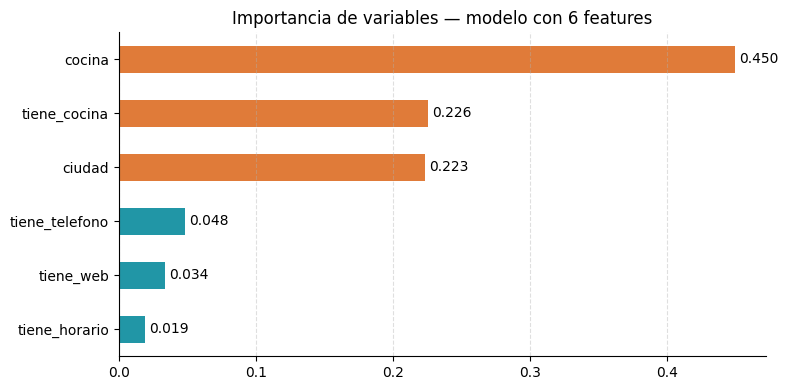

In [14]:
importancias2 = pd.Series(
    clf2.feature_importances_,
    index=["cocina", "ciudad", "tiene_telefono", "tiene_web", "tiene_horario", "tiene_cocina"]
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colores_imp = ["#2196a6" if v < 0.2 else "#e07b39" for v in importancias2]
importancias2.plot(kind="barh", ax=ax, color=colores_imp)
ax.set_title("Importancia de variables — modelo con 6 features")
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../docs/importancia_features_v2.png", dpi=150, bbox_inches="tight")
plt.show()